# Question 01

In [ ]:
import cv2 as cv
import numpy as np

image_1b = cv.imread('a1images/emma.jpg')

c = np.array([(50,100),(150,255)])

transform = np.arange(256,dtype='uint8')

transform[c[0,0]:c[0,1]+1] = np.linspace(c[1,0],c[1,1],c[0,1]-c[0,0]+1).astype('uint8')

image_1b_out = cv.LUT(image_1b,transform)

cv.imshow('image_1b_out', image_1b_out)
cv.waitKey(0)
cv.destroyAllWindows()

# Question 02

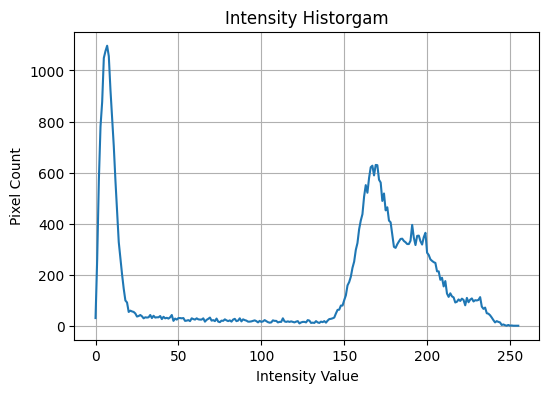

In [3]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

image_2 = cv.imread('a1images/brain_proton_density_slice.png',cv.IMREAD_GRAYSCALE)

histogram = cv.calcHist([image_2], [0], None, [256], [0, 256])

plt.figure(figsize=(6, 4))
plt.plot(histogram)
plt.title('Intensity Historgam')
plt.xlabel('Intensity Value')
plt.ylabel('Pixel Count')
plt.grid(True)
plt.show()

In [37]:
#Grey Matter --> 150-190
import cv2 as cv
import numpy as np

image_2 = cv.imread('a1images/brain_proton_density_slice.png', cv.IMREAD_GRAYSCALE)

c = np.array([(150,190),(200,255)])
ri = 30 # reduced intensity

transform = np.arange(256, dtype='uint8')

transform[0:c[0,0]+1] = np.linspace(0, c[0,0]-ri, c[0,0]+1).astype('uint8')
transform[c[0,0]:c[0,1]+1] = np.linspace(c[1,0], c[1,1], c[0,1]-c[0,0]+1).astype('uint8') # Grey Matter boosted
transform[c[0,1]+1:256] = np.linspace(c[1,1]-ri, 255, 256-(c[0,1]+1)).astype('uint8')

image_2_out_1 = cv.LUT(image_2, transform)

cv.imshow('image_2_out_1', image_2_out_1)
cv.waitKey(0)
cv.destroyAllWindows()

In [ ]:
#White Matter --> 190 -255

import cv2 as cv
import numpy as np

image_2 = cv.imread('a1images/brain_proton_density_slice.png', cv.IMREAD_GRAYSCALE)

c = np.array([(190,255),(245,255)])
ri = 30 # reduced intensity

transform = np.arange(256, dtype='uint8')

transform[0:c[0,0]+1] = np.linspace(0, c[0,0]-ri, c[0,0]+1).astype('uint8')
transform[c[0,0]:c[0,1]+1] = np.linspace(c[1,0], c[1,1], c[0,1]-c[0,0]+1).astype('uint8') # Grey Matter boosted
transform[c[0,1]+1:256] = np.linspace(c[1,1]-ri, 255, 256-(c[0,1]+1)).astype('uint8')

image_2_out_1 = cv.LUT(image_2, transform)

cv.imshow('image_2_out_1', image_2_out_1)
cv.waitKey(0)
cv.destroyAllWindows()

# Question 03

In [43]:
import cv2 as cv
import numpy as np

gamma = 2.2

image_3 = cv.imread('a1images/highlights_and_shadows.jpg')
lab = cv.cvtColor(image_3, cv.COLOR_BGR2Lab)
L, a, b = cv.split(lab)

gamma_LUT = np.array([((i / 255.0) ** gamma) * 255 for i in np.arange(256)]).astype("uint8")

L_gamma = cv.LUT(L, gamma_LUT)
lab_gamma = cv.merge([L_gamma, a, b])

image_3_out = cv.cvtColor(lab_gamma, cv.COLOR_Lab2BGR)

cv.imshow("Original", image_3)
cv.imshow("Gamma Corrected", image_3_out)
cv.waitKey(0)
cv.destroyAllWindows()

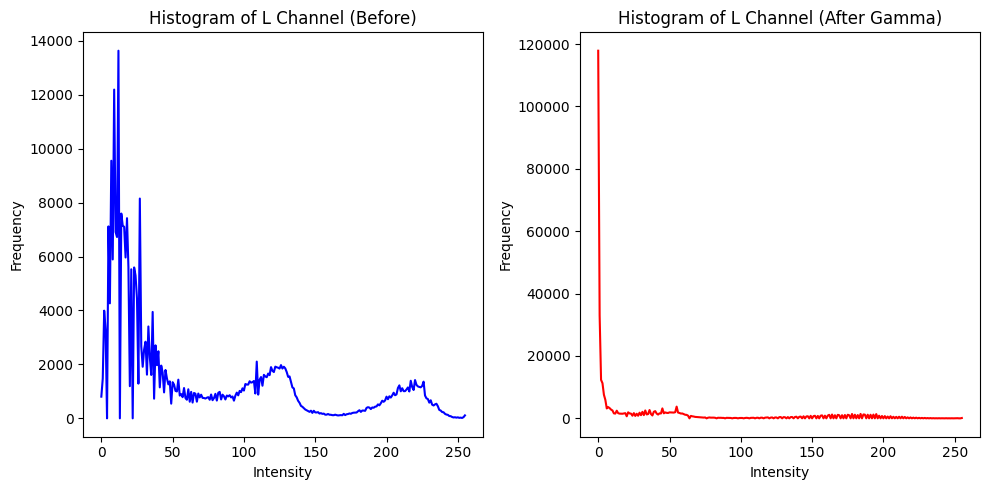

In [44]:
hist_before = cv.calcHist([L], [0], None, [256], [0,256])

hist_after = cv.calcHist([L_gamma], [0], None, [256], [0,256])

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(hist_before, color='blue')
plt.title("Histogram of L Channel (Before)")
plt.xlabel("Intensity")
plt.ylabel("Frequency")

plt.subplot(1,2,2)
plt.plot(hist_after, color='red')
plt.title("Histogram of L Channel (After Gamma)")
plt.xlabel("Intensity")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# Question 04

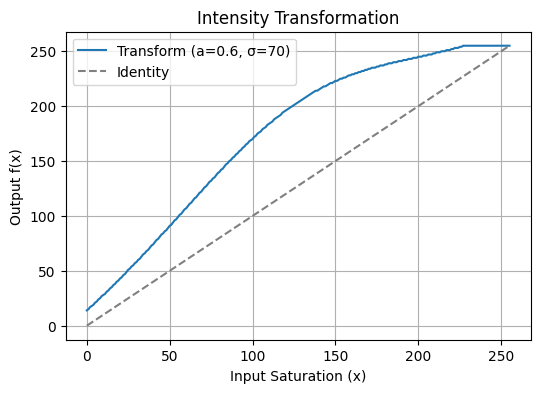

In [4]:
import cv2 as cv
import numpy as np

image_4 = cv.imread('a1images/spider.png')

hsv = cv.cvtColor(image_4, cv.COLOR_BGR2HSV)
H, S, V = cv.split(hsv)

sigma = 70
a = 0.6

x = np.arange(256)
transform = x + a * 128 * np.exp(-((x - 128) ** 2) / (2 * sigma ** 2))
transform = np.clip(transform, 0, 255).astype(np.uint8)

S_new = cv.LUT(S, transform)

hsv_new = cv.merge([H, S_new, V])
image_vibrant = cv.cvtColor(hsv_new, cv.COLOR_HSV2BGR)

cv.imshow("Original", image_4)
cv.imshow("Vibrance Enhanced", image_vibrant)

plt.figure(figsize=(6,4))
plt.plot(x, transform, label=f"Transform (a={a}, σ={sigma})")
plt.plot(x, x, '--', color='gray', label="Identity")
plt.xlabel("Input Saturation (x)")
plt.ylabel("Output f(x)")
plt.title("Intensity Transformation")
plt.legend()
plt.grid(True)
plt.show()

cv.waitKey(0)
cv.destroyAllWindows()


# Question 05

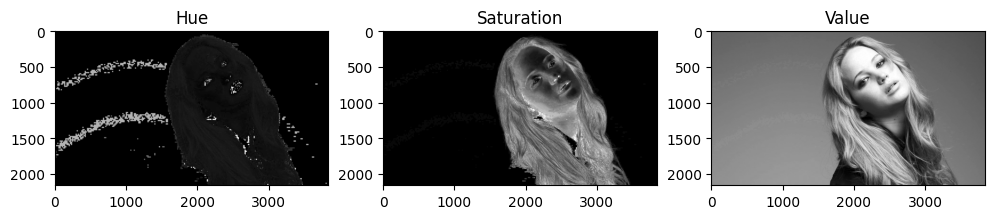

In [5]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img = cv.imread("a1images/jeniffer.jpg")
hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)
h, s, v = cv.split(hsv)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1); plt.imshow(h, cmap='gray'); plt.title("Hue")
plt.subplot(1, 3, 2); plt.imshow(s, cmap='gray'); plt.title("Saturation")
plt.subplot(1, 3, 3); plt.imshow(v, cmap='gray'); plt.title("Value")
plt.show()

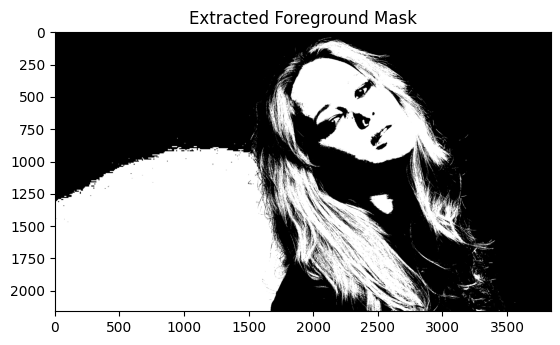

In [7]:
_, mask = cv.threshold(v, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

plt.imshow(mask, cmap='gray'); plt.title("Extracted Foreground Mask"); plt.show()

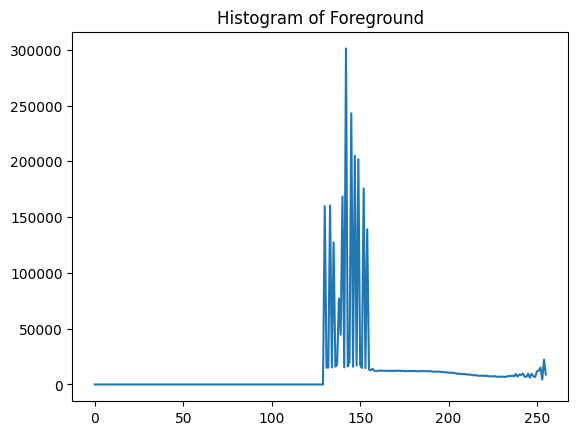

In [8]:
foreground = cv.bitwise_and(v, v, mask=mask)
hist = cv.calcHist([foreground], [0], mask, [256], [0,256])
plt.plot(hist); plt.title("Histogram of Foreground"); plt.show()

In [9]:
L = 256                     # Number of intensity levels
MN = np.sum(mask > 0)       # Total number of pixels in foreground

cdf = hist.cumsum()
cdf_normalized = cdf / MN   

t = np.array([(L - 1) * cdf_normalized[k] for k in range(L)], dtype=np.uint8)

equalized_foreground = t[foreground]

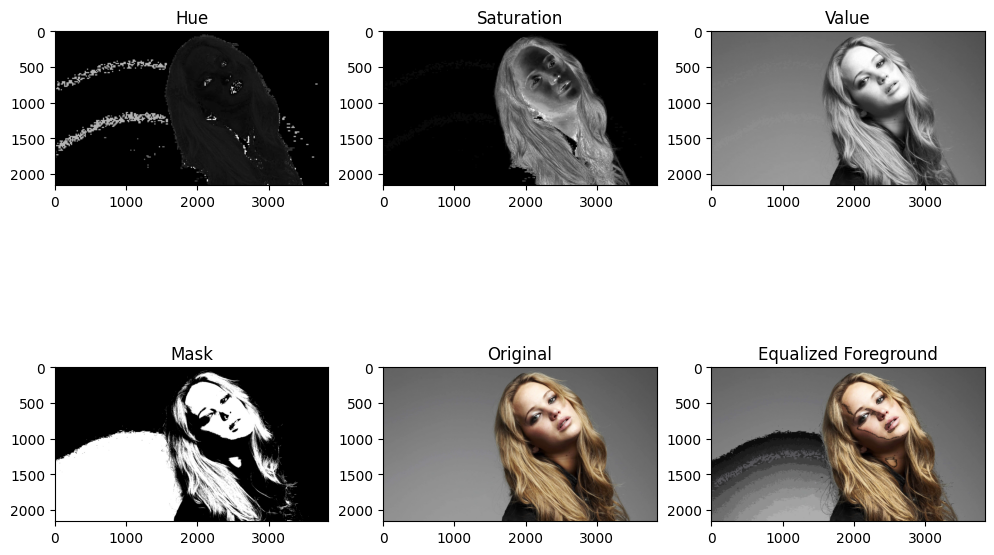

In [10]:
background = cv.bitwise_and(v, v, mask=cv.bitwise_not(mask))
result_v = cv.add(background, equalized_foreground)


result_hsv = cv.merge([h, s, result_v])
result_img = cv.cvtColor(result_hsv, cv.COLOR_HSV2BGR)


plt.figure(figsize=(12, 8))
plt.subplot(2, 3, 1); plt.imshow(h, cmap='gray'); plt.title("Hue")
plt.subplot(2, 3, 2); plt.imshow(s, cmap='gray'); plt.title("Saturation")
plt.subplot(2, 3, 3); plt.imshow(v, cmap='gray'); plt.title("Value")
plt.subplot(2, 3, 4); plt.imshow(mask, cmap='gray'); plt.title("Mask")
plt.subplot(2, 3, 5); plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB)); plt.title("Original")
plt.subplot(2, 3, 6); plt.imshow(cv.cvtColor(result_img, cv.COLOR_BGR2RGB)); plt.title("Equalized Foreground")
plt.show()